# Эксперимент 7: Многослойный декодер (DPT-style)

**Гипотеза:** Финальный слой DINOv2 содержит семантические признаки высокого уровня, но не текстурные детали, нужные для классов 1 и 2. Ранние слои ViT сохраняют низкоуровневые текстурные признаки.

**Ключевое изменение:** Извлекаем признаки из 4 промежуточных слоёв DINOv2 (вместо одного финального) и объединяем их в глубоком декодере.

```
Слой 3  → низкоуровневые края и текстуры  ← важно для классов 1, 2
Слой 6  → паттерны средней детализации
Слой 9  → структурные признаки
Слой 11 → семантика высокого уровня        ← то, что использовалось раньше
```

- Вход: 224×1400 (правильное соотношение сторон из Эксп.5)
- Данные: 200 реальных изображений (те же условия, что Эксп.5)
- Backbone: заморожен
- Декодер: ~2.8М параметров (против 566К в Эксп.5)

> **v2** — исправлен баг: `JointTransform` применяет flip и crop **одновременно** к изображению и маске.

## 1. Импорты и конфигурация

In [1]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

# ── Размер входа (те же, что Эксп.5) ──────────────────────────────────────────
IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

# ── Какие промежуточные слои брать (0-индексация, всего 12 блоков) ────────────
# Слои: ранний (3), средне-ранний (5), средне-поздний (8), финальный (11)
INTERMEDIATE_LAYERS = [3, 5, 8, 11]

BATCH_SIZE  = 4
EPOCHS      = 75
LR_HEAD     = 1e-3
N_SELECT    = 200
TEST_SIZE   = 0.2

print(f'\nВход:            {IMG_H}x{IMG_W}  (1:{IMG_W//IMG_H})')
print(f'Патч-сетка:      {PATCH_H}x{PATCH_W} = {PATCH_H*PATCH_W} патчей')
print(f'Маска (выход):   {MASK_H}x{MASK_W}')
print(f'Слои DINOv2:     {INTERMEDIATE_LAYERS}')
print(f'Отбор:           {N_SELECT} изображений')
print(f'CSV: {os.path.exists(TRAIN_CSV)}  IMG: {os.path.exists(TRAIN_IMG_DIR)}')

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:            224x1400  (1:6)
Патч-сетка:      16x100 = 1600 патчей
Маска (выход):   64x400
Слои DINOv2:     [3, 5, 8, 11]
Отбор:           200 изображений
CSV: True  IMG: True


## 2. Вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def get_label(img_id, df):
    cls = get_classes(img_id, df)
    return cls[0] if cls else 0


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Функции определены.')

Строк: 7,095  |  Изображений: 6,666
Функции определены.


## 3. Dataset (224×1400)

In [3]:
FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3


class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h       = img_h
        self.img_w       = img_w
        self.is_train    = is_train
        self.flip_p      = flip_p
        self.crop_scale  = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor   = transforms.ToTensor()
        self.normalize   = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir
        self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, img_id


print(f'JointTransform + SteelSegDataset определены. Маска: {MASK_H}x{MASK_W}')
print(f'Аугментации: flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

JointTransform + SteelSegDataset определены. Маска: 64x400
Аугментации: flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 (заморожен)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE).eval()
for p in dinov2.parameters():
    p.requires_grad = False

total = sum(p.numel() for p in dinov2.parameters()) / 1e6
print(f'DINOv2 ViT-B/14: {total:.1f}М параметров (заморожен)')

# Проверяем get_intermediate_layers — ключевой API для этого эксперимента
with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    print(f'get_intermediate_layers вернул {len(feats)} тензоров:')
    for i, (layer_idx, f) in enumerate(zip(INTERMEDIATE_LAYERS, feats)):
        print(f'  Слой {layer_idx:2d}: {tuple(f.shape)}')
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats), 'Ошибка размера!'
    print('OK — все слои имеют правильную форму')
del test_img, feats

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров (заморожен)
get_intermediate_layers вернул 4 тензоров:
  Слой  3: (1, 1600, 768)
  Слой  5: (1, 1600, 768)
  Слой  8: (1, 1600, 768)
  Слой 11: (1, 1600, 768)
OK — все слои имеют правильную форму


## 5. Эмбеддинги (для отбора)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')

if os.path.exists(emb_cache):
    print('Загружаем эмбеддинги из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t):
            self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

Загружаем эмбеддинги из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор 200 изображений

In [6]:
def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, df,
                              n_per_class=50, n_total=N_SELECT):
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in get_classes(i, df)]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_ids.index(i) for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


all_labels  = [get_label(i, train_df) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

pool_mask    = [emb_ids.index(i) for i in train_ids]
pool_embeds  = embeddings[pool_mask]
selected_ids = stratified_active_select(
    pool_embeds, train_ids, train_df, n_per_class=50, n_total=N_SELECT)
print(f'Итого отобрано: {len(selected_ids)}')

Train pool: 5,332  |  Test: 1,334
Отбор: 199 гарант. + 1 KMeans = 200
Итого отобрано: 200


## 7. Архитектура: SegHeadDPT

Декодер берёт признаки из 4 слоёв DINOv2 одновременно:

```
DINOv2 слои 3,5,8,11  →  [B, 1600, 768] × 4
  ↓  proj (768→256) × 4
  ↓  cat → [B, 1024, 16, 100]
  ↓  fuse conv → [B, 256, 16, 100]
  ↓  upsample ×2 → [B, 128, 32, 200]
  ↓  conv block
  ↓  upsample ×2 → [B, 64, 64, 400]
  ↓  conv → [B, 5, 64, 400]
```

In [7]:
class SegHeadDPT(nn.Module):
    """
    Многослойный декодер. Принимает список из 4 наборов патч-токенов
    от разных слоёв DINOv2 и объединяет их в карту сегментации.
    """
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers

        # Проекция каждого слоя: 768 → 256 (1×1 conv)
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256),
                nn.GELU(),
            ) for _ in range(n_layers)
        ])

        # Слияние всех слоёв: 256*4=1024 → 256
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )

        # Декодер: 16x100 → 32x200 → 64x400
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        # features: список из n_layers тензоров [B, N, embed_dim]
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            # Разворачиваем в 2D патч-сетку
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0, 3, 1, 2)
            maps.append(self.proj[i](x))  # [B, 256, 16, 100]
        x = torch.cat(maps, dim=1)       # [B, 1024, 16, 100]
        x = self.fuse(x)                 # [B, 256, 16, 100]
        x = self.up1(x)                  # [B, 128, 32, 200]
        x = self.up2(x)                  # [B, 64, 64, 400]
        return self.head(x)              # [B, num_classes, 64, 400]


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s=smooth
    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0,3,1,2).float()
        i       = (p*t).sum(dim=(2,3))
        u       = p.sum(dim=(2,3)) + t.sum(dim=(2,3))
        return 1 - ((2*i+self.s)/(u+self.s)).mean()


# Проверка архитектуры
_h = SegHeadDPT().to(DEVICE)
n_params = sum(p.numel() for p in _h.parameters())
with torch.no_grad():
    dummy_feats = [torch.randn(2, PATCH_H*PATCH_W, EMBED_DIM).to(DEVICE)
                   for _ in range(4)]
    out = _h(dummy_feats)
print(f'SegHeadDPT: {n_params:,} параметров  (Эксп.5 голова: 566,213)')
print(f'Выход: {tuple(out.shape)}  (ожидалось: (2, {NUM_CLASSES}, {MASK_H}, {MASK_W}))')
assert out.shape == (2, NUM_CLASSES, MASK_H, MASK_W), 'Ошибка размера!'
print('OK')
del _h, dummy_feats, out

SegHeadDPT: 2,845,381 параметров  (Эксп.5 голова: 566,213)
Выход: (2, 5, 64, 400)  (ожидалось: (2, 5, 64, 400))
OK


## 8. Функция обучения

In [8]:
def train_head(train_ids, val_ids, df,
               n_epochs=EPOCHS, lr=LR_HEAD, label='',
               checkpoint_every=25):
    head  = SegHeadDPT().to(DEVICE)
    opt   = optim.AdamW(head.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw)
    cdice = DiceLoss()

    tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)
    vds = SteelSegDataset(val_ids,   TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    print(f'Параметры головы: {sum(p.numel() for p in head.parameters()):,}')

    for ep in range(1, n_epochs+1):
        head.train(); tl = 0.0
        for imgs, masks, _ in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with torch.no_grad():
                # Ключевое отличие: get_intermediate_layers вместо forward_features
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            lg   = head(feats)
            loss = cce(lg, masks) + 0.5 * cdice(lg, masks)
            opt.zero_grad(); loss.backward(); opt.step()
            tl  += loss.item()
        sched.step()

        head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                iou.update(head(feats).argmax(1), masks)
        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl/len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())
        if mi > best:
            best = mi
            best_state = {k: v.clone() for k, v in head.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i,v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_v2_ep{ep}.pt')
            torch.save({'epoch':ep, 'model_state':head.state_dict(),
                        'history':hist, 'best_miou':best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    # Загружаем лучшие веса
    head.load_state_dict(best_state)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 9. Обучение

In [9]:
print('='*60)
print(f'ЭКСП.7: {N_SELECT} реал., вход {IMG_H}x{IMG_W}, слои {INTERMEDIATE_LAYERS}')
print('='*60)
model_dpt, history_dpt = train_head(
    selected_ids, test_ids, train_df,
    label='DPT'
)

ЭКСП.7: 200 реал., вход 224x1400, слои [3, 5, 8, 11]
Веса классов:
  Фон: 0.100  (78,181,311 пикс.)
  Дефект 1: 1.991  (236,225 пикс.)
  Дефект 2: 2.428  (193,649 пикс.)
  Дефект 3: 0.257  (1,832,305 пикс.)
  Дефект 4: 0.318  (1,476,510 пикс.)
Обучающих: 200  |  Валидационных: 1334
Параметры головы: 2,845,381
[DPT] Эп   1/75 | Loss:1.4933 | mIoU:0.1895 | cls0:0.880  cls1:0.019  cls2:0.005  cls3:0.004  cls4:0.039
[DPT] Эп  10/75 | Loss:0.5060 | mIoU:0.4305 | cls0:0.950  cls1:0.126  cls2:0.112  cls3:0.448  cls4:0.517
[DPT] Эп  20/75 | Loss:0.3556 | mIoU:0.4235 | cls0:0.932  cls1:0.075  cls2:0.117  cls3:0.418  cls4:0.575
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_DPT_v2_ep25.pt
[DPT] Эп  30/75 | Loss:0.1936 | mIoU:0.5131 | cls0:0.957  cls1:0.269  cls2:0.288  cls3:0.492  cls4:0.559
[DPT] Эп  40/75 | Loss:0.1398 | mIoU:0.5045 | cls0:0.957  cls1:0.248  cls2:0.261  cls3:0.487  cls4:0.570
[DPT] Эп  50/75 | Loss:0.1181 | mIoU:0.5177 | cls0:0.961  cls1:0.277  cls2:0.281  cls3

## 10. Сравнение с Эксп.5

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.5  Один финальный слой  (200 реал., 224x1400): mIoU = 0.4219
  Эксп.7  Четыре слоя / DPT    (200 реал., 224x1400): mIoU = 0.5248
  Прирост многослойного декодера: +10.3%

  Класс            Эксп.5     Эксп.7    Прирост
  ----------------------------------------------
  Фон              0.9506     0.9597      +0.9%
  Дефект 1         0.1071     0.2718     +16.5%
  Дефект 2         0.1095     0.3245     +21.5%
  Дефект 3         0.4194     0.4925      +7.3%
  Дефект 4         0.5229     0.5754      +5.3%


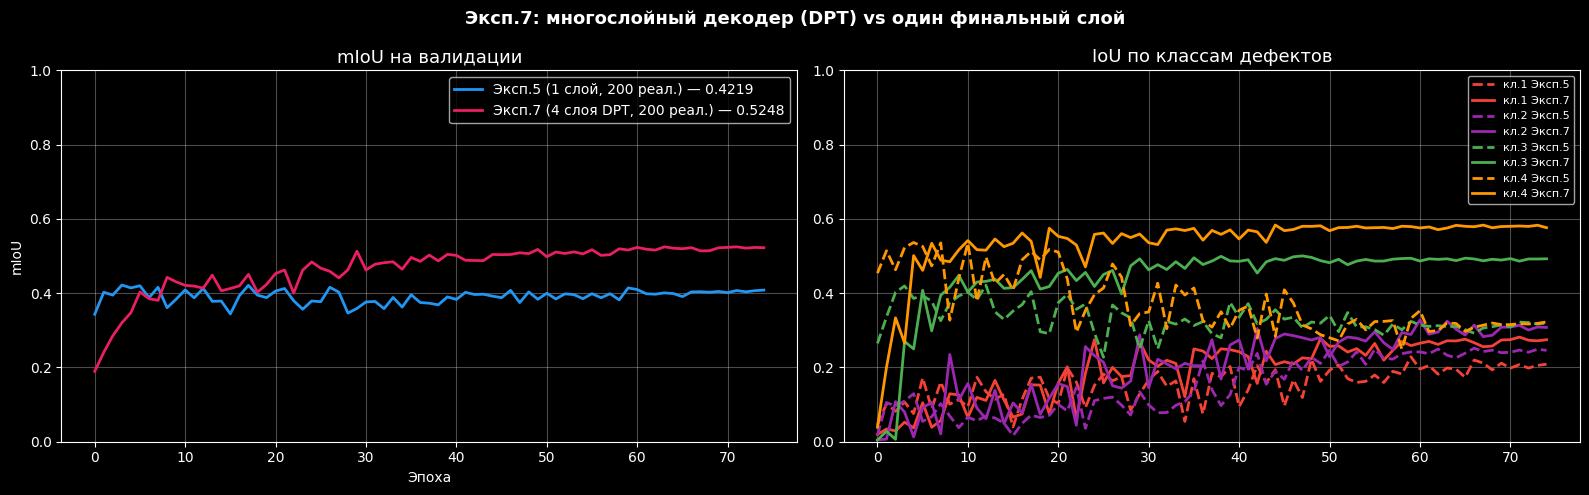

In [10]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

# Лучшее значение DPT
m_dpt = max(history_dpt['val_miou'])
e_dpt = int(np.argmax(history_dpt['val_miou']))
i_dpt = history_dpt['val_iou_per_class'][e_dpt]

# Загружаем Эксп.5 для сравнения
history_ar_path = os.path.join(save_dir, 'history_ar.json')
if os.path.exists(history_ar_path):
    with open(history_ar_path) as f:
        history_ar = json.load(f)
    m_ar  = max(history_ar['val_miou'])
    e_ar  = int(np.argmax(history_ar['val_miou']))
    i_ar  = history_ar['val_iou_per_class'][e_ar]
    has_ar = True
else:
    has_ar = False

print('ИТОГОВОЕ СРАВНЕНИЕ:')
if has_ar:
    print(f'  Эксп.5  Один финальный слой  (200 реал., 224x1400): mIoU = {m_ar:.4f}')
print(f'  Эксп.7  Четыре слоя / DPT    (200 реал., 224x1400): mIoU = {m_dpt:.4f}')
if has_ar:
    print(f'  Прирост многослойного декодера: {(m_dpt-m_ar)*100:+.1f}%')

if has_ar:
    print(f'\n  {"Класс":<12} {"Эксп.5":>10} {"Эксп.7":>10} {"Прирост":>10}')
    print('  ' + '-'*46)
    for c, (ar, dpt) in enumerate(zip(i_ar, i_dpt)):
        print(f'  {names[c]:<12} {ar:>10.4f} {dpt:>10.4f} {(dpt-ar)*100:>+9.1f}%')
else:
    for c, v in enumerate(i_dpt):
        print(f'  {names[c]:<12} {v:>10.4f}')

# ── Графики ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if has_ar:
    axes[0].plot(history_ar['val_miou'],  color='#2196F3', lw=2,
                 label=f'Эксп.5 (1 слой, 200 реал.) — {m_ar:.4f}')
axes[0].plot(history_dpt['val_miou'], color='#E91E63', lw=2,
             label=f'Эксп.7 (4 слоя DPT, 200 реал.) — {m_dpt:.4f}')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

colors_cls = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
for cls, col in colors_cls.items():
    if has_ar:
        axes[1].plot([h[cls] for h in history_ar['val_iou_per_class']],
                     color=col, lw=2, ls='--', label=f'кл.{cls} Эксп.5')
    axes[1].plot([h[cls] for h in history_dpt['val_iou_per_class']],
                 color=col, lw=2, ls='-', label=f'кл.{cls} Эксп.7')
axes[1].set_title('IoU по классам дефектов', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)
plt.suptitle('Эксп.7: многослойный декодер (DPT) vs один финальный слой',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Сохранение

In [11]:
torch.save(model_dpt.state_dict(),
           os.path.join(save_dir, 'model_dpt_4layers_v2.pt'))
with open(os.path.join(save_dir, 'history_dpt_v2.json'), 'w') as f:
    json.dump(history_dpt, f)
print(f'Сохранено: model_dpt_4layers.pt  +  history_dpt.json')
print(f'Директория: {save_dir}')

Сохранено: model_dpt_4layers.pt  +  history_dpt.json
Директория: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads
